# Movie Recommender System

Анализ датасета MovieLens 100K: исследование данных через SQL, подготовка train/test split по времени.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## 1. Загрузка данных

Загружаем три файла MovieLens и сохраняем их в базу данных SQLite для дальнейшего анализа через SQL.

In [2]:
ratings = pd.read_csv("../data/ml-100k/u.data", sep="\t", header=None, names=['user_id', 'item_id', 'rating', 'timestamp'])
users = pd.read_csv("../data/ml-100k/u.user", sep="|", header=None, names=['user_id', 'age', 'gender', 'occupation', 'zip'])
movies = pd.read_csv("../data/ml-100k/u.item", sep="|", header=None, encoding="latin-1", usecols=[0, 1, 2], names=["item_id", "title", "release_date"])

conn = sqlite3.connect('../data/movielens.db')

ratings.to_sql('ratings', conn, if_exists='replace', index=False)
users.to_sql('users', conn, if_exists='replace', index=False)
movies.to_sql('movies', conn, if_exists='replace', index=False)

pd.read_sql_query("SELECT COUNT(*) AS n FROM ratings", conn)

,n
0,100000


## 2. Размеры датасета

Считаем количество оценок, уникальных фильмов и пользователей.

In [3]:
pd.read_sql_query("SELECT COUNT(*) AS n, COUNT(DISTINCT item_id) AS cnt_movies, COUNT(DISTINCT user_id) AS cnt_users FROM ratings", conn)

,n,cnt_movies,cnt_users
0,100000,1682,943


## 3. Топ фильмов по количеству оценок

JOIN с таблицей movies нужен, чтобы получить названия фильмов вместо ID.

In [4]:
pd.read_sql_query("""SELECT ratings.item_id, movies.title, COUNT(*) AS num_rat
FROM ratings
JOIN movies ON ratings.item_id = movies.item_id
GROUP BY ratings.item_id, movies.title
ORDER BY num_rat DESC
LIMIT 10""", conn)

,item_id,title,num_rat
0,50,Star Wars (1977),583
1,258,Contact (1997),509
2,100,Fargo (1996),508
3,181,Return of the Jedi (1983),507
4,294,Liar Liar (1997),485
5,286,"English Patient, The (1996)",481
6,288,Scream (1996),478
7,1,Toy Story (1995),452
8,300,Air Force One (1997),431
9,121,Independence Day (ID4) (1996),429


## 4. Топ активных пользователей

Здесь JOIN не нужен — все данные есть в таблице ratings.

In [5]:
pd.read_sql_query("""SELECT user_id, COUNT(*) AS num_ratings
FROM ratings
GROUP BY user_id
ORDER BY num_ratings DESC
LIMIT 10""", conn)

,user_id,num_ratings
0,405,737
1,655,685
2,13,636
3,450,540
4,276,518
5,416,493
6,537,490
7,303,484
8,234,480
9,393,448


## 5. Топ фильмов по возрастным группам

Разбиваем пользователей на 4 возрастные группы через CASE WHEN. Считаем средний рейтинг фильмов в каждой группе, оставляя только фильмы с 20+ оценками.

In [6]:
df = pd.read_sql_query("""SELECT      
    CASE
        WHEN users.age<25 THEN "young"
        WHEN users.age<40 THEN "middle"
        WHEN users.age<60 THEN "adult"
        ELSE "senior"
    END AS age_group, 
    movies.title AS title, 
    COUNT(*) AS num_rating,
    AVG(ratings.rating) AS avg_rating
FROM ratings
JOIN movies ON movies.item_id=ratings.item_id
JOIN users ON users.user_id=ratings.user_id
GROUP BY age_group, movies.title
HAVING COUNT(*)>=20
ORDER BY age_group ASC, avg_rating DESC
""", conn)

for group in ["young", "middle", "adult", "senior"]:
    ss = df[df["age_group"]==group].head(10)
    print(f"\n{group} :")
    print(ss[['title', 'num_rating', 'avg_rating']])


young :
                                                  title  num_rating  \
1063                   Shawshank Redemption, The (1994)          75   
1064                                  Casablanca (1942)          37   
1065                                     Titanic (1997)          96   
1066  Dr. Strangelove or: How I Learned to Stop Worr...          34   
1067                    Empire Strikes Back, The (1980)         100   
1068                           Good Will Hunting (1997)          51   
1069                              Godfather, The (1972)          86   
1070                                   Star Wars (1977)         145   
1071                         Usual Suspects, The (1995)          83   
1072                                12 Angry Men (1957)          29   

      avg_rating  
1063    4.640000  
1064    4.621622  
1065    4.531250  
1066    4.500000  
1067    4.480000  
1068    4.470588  
1069    4.465116  
1070    4.462069  
1071    4.445783  
1072    4.413793  


In [7]:
pd.read_sql_query("""SELECT 
    CASE 
        WHEN age < 25 THEN 'young'
        WHEN age < 40 THEN 'middle'
        WHEN age < 60 THEN 'adult'
        ELSE 'senior'
    END AS age_group,
    COUNT(*) AS num_users
FROM users
GROUP BY age_group
ORDER BY num_users DESC
""", conn)

,age_group,num_users
0,middle,416
1,adult,262
2,young,234
3,senior,31


## 6. Распределение оценок

Bar chart: сколько раз пользователи ставили оценки 1, 2, 3, 4, 5. Оценки — категории, поэтому используем bar chart, а не histogram.

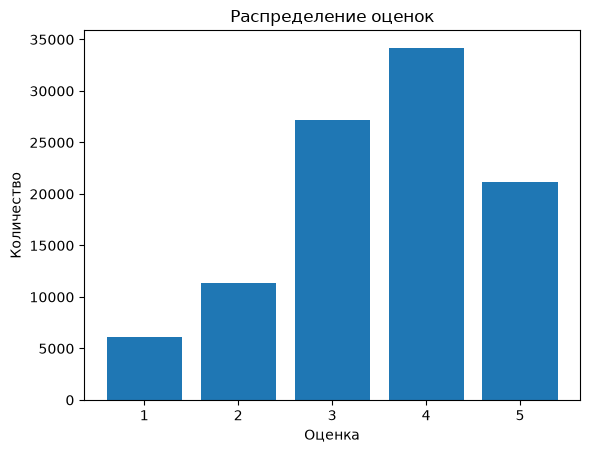

In [8]:
rating_count = pd.read_sql_query("""SELECT rating, COUNT (*) AS CNT
FROM ratings
GROUP BY rating
ORDER BY rating ASC
""", conn)

plt.bar(rating_count['rating'], rating_count['CNT'])
plt.xlabel("Оценка")
plt.ylabel("Количество")
plt.title("Распределение оценок")
plt.savefig('../reports/figures/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Активность пользователей

Гистограмма: как распределено количество оценок по пользователям. У 943 пользователей разное число оценок — histogram показывает, в каком диапазоне большинство.

In [12]:
user_activity = pd.read_sql_query("""SELECT user_id, COUNT (*) AS num_of_users_rating
FROM ratings
GROUP BY user_id
""", conn)

print(user_activity.head(10))
print(user_activity.shape)

   user_id  num_of_users_rating
0        1                  272
1        2                   62
2        3                   54
3        4                   24
4        5                  175
5        6                  211
6        7                  403
7        8                   59
8        9                   22
9       10                  184
(943, 2)


## 8. Train/test split по времени

Делим данные так, чтобы последние 20% оценок каждого пользователя попали в test. Используем оконную функцию ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY timestamp) — нумеруем оценки каждого пользователя по времени.

In [10]:
data_split = pd.read_sql_query("""
WITH ranked AS (
    SELECT 
        user_id, 
        item_id, 
        rating,
        timestamp, 
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY timestamp) AS rn, 
        COUNT(*) OVER (PARTITION BY user_id) AS total
    FROM ratings
)
SELECT 
    user_id, 
    item_id, 
    rating,
    CASE 
        WHEN rn<=0.8 * total THEN "train"
        ELSE "test"
    END AS split
FROM ranked
""", conn)

print(data_split.shape)
print(data_split['split'].value_counts())

train = data_split[data_split['split']=="train"]
test = data_split[data_split['split']=="test"]

print(train.shape)
print(test.shape)

(100000, 4)
split
train    79619
test     20381
Name: count, dtype: int64
(79619, 4)
(20381, 4)


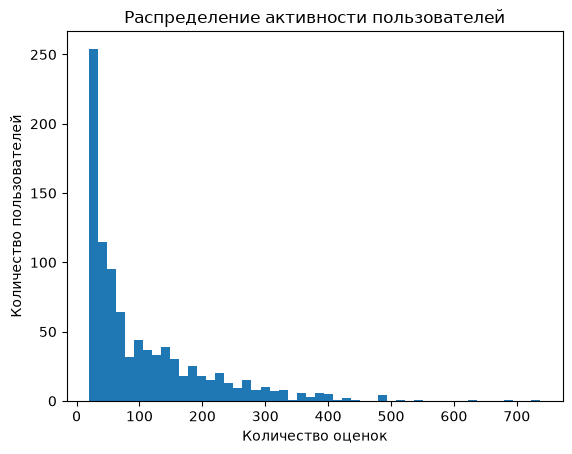

In [11]:
plt.hist(user_activity['num_of_users_rating'], bins=50)
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')
plt.title('Распределение активности пользователей')
plt.savefig('../reports/figures/user_activity.png', dpi=150, bbox_inches='tight') 
plt.show()